In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import MONITORING_DATA, color_mapping, site_order, class_it_mapping, fig_class_order

In [7]:

pflux  = MONITORING_DATA / "Tables_PollenCounts/qualibratedfluxes_all.csv" # qualibratedfluxes_withCI_all.csv"

p_save_fig = MONITORING_DATA / "Figures_Values/"

p_figtables= MONITORING_DATA /"4.Tables_for_figures/"


In [ ]:
df_all = pd.read_csv(pflux)
df_all.head()

,class,site,year,site_year,class_num,count,nb_ly_persample,count_ly,count_tot_trap,flux_cm2_an
0,Buxus,D1,2019,D1_2019,2,53.806745,9666,38.870025,13380.387225,681.457526
1,Buxus,D1,2020,D1_2020,2,41.644678,38664,1009.650010,1594.760392,81.220480
2,Buxus,D1,2021,D1_2021,2,24.990120,73628,504.100635,3650.010439,185.893505
3,Buxus,D2,2020,D2_2020,2,27.706941,38664,956.324311,1120.186082,57.050609
4,Buxus,D2,2021,D2_2021,2,30.323475,73628,727.306476,3069.760699,156.341629


In [ ]:

li_class_remove = ['Lycopodium', 'NonPollen',]
df_total_flux=df_all[~df_all["class"].isin(li_class_remove)]

print(set(list(df_total_flux["class"])))
df_total_flux=df_total_flux[["site", "year", "site_year", "flux_cm2_an"]].groupby(["site", "year", "site_year"]).sum().reset_index()
df_total_flux.head()


{'Poaceae', 'Pinaceae', 'VitisF', 'Buxus', 'VitisS', 'Plantago', 'Cupressaceae', 'IndetBlurry', 'QuercusDeciduous', 'QuercusIlex', 'Pistacia', 'Fraxinus', 'IndetCovered', 'Other', 'Olea', 'Phillyrea'}


,site,year,site_year,flux_cm2_an
0,D1,2019,D1_2019,14184.721639
1,D1,2020,D1_2020,7782.759780
2,D1,2021,D1_2021,21184.709351
3,D2,2020,D2_2020,7451.530871
4,D2,2021,D2_2021,26223.790228


In [10]:


df_total_flux['site'] = pd.Categorical(df_total_flux['site'], categories=site_order, ordered=True)

years = sorted(df_total_flux['year'].unique())
colors = sns.color_palette("Greys", n_colors=len(years))
colors = [plt.cm.Greys(x) for x in np.linspace(0.3, 0.9, len(years))]

agg = df_total_flux.groupby('site')['flux_cm2_an'].agg(['mean', 'std', 'count']).reset_index()
agg["twoSE"] = 2 * agg["std"] / np.sqrt(agg["count"])

agg

,site,mean,std,count,twoSE
0,W1,40749.339369,26241.942627,5,23471.507030
1,W2,36495.937969,10760.885040,5,9624.828179
2,W3,33735.010016,4764.610047,4,4764.610047
3,W4,34231.947001,13455.379713,5,12034.857480
4,D1,14384.063590,6703.198191,3,7740.186560
5,D2,21963.143334,9722.843680,4,9722.843680
6,D3,26796.772578,9499.055665,2,13433.693351


#### The file used to plot the figure is also available in the ZENODO repository : 


In [ ]:
# saving intermediary table used to plot the figure
agg = pd.read_csv(p_figtables / "table_figSI_flux_notaxa.csv" )


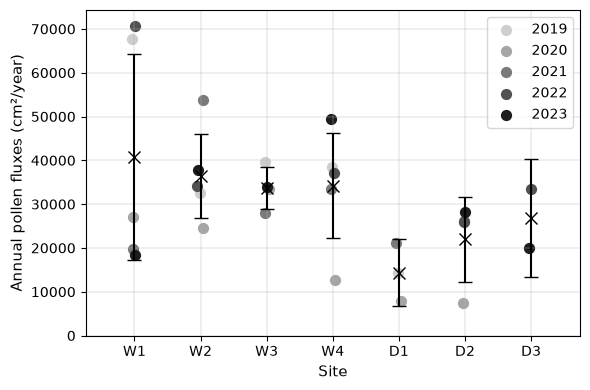

In [14]:


plt.figure(figsize=(6,4))
plt.bar(agg['site'], agg['mean'], yerr=agg['twoSE'], color='gainsboro', alpha=0, ecolor="black",  capsize=5) 

plt.plot(agg['site'], agg['mean'], color='black', zorder=3, marker='x', markersize=8, fillstyle="none",  linestyle='None')

for i, year in enumerate(years):
    data_year = df_total_flux[df_total_flux['year'] == year]
    jitter = np.random.uniform(-0.05, 0.05, size=len(data_year)) 
    x_positions = data_year['site'].cat.codes + jitter
    plt.scatter(x_positions, 
                data_year['flux_cm2_an'],
                color=colors[i],
                label=str(year),
                s=50)


plt.ylabel("Annual pollen fluxes (cm²/year)", fontsize=11)
plt.xlabel("Site", fontsize=11)
plt.title("")
plt.tight_layout()
plt.legend(title="")
plt.grid(True, linewidth=0.3)
plt.tight_layout()

plt.savefig(p_save_fig/"annualflux_notaxa_perSite.pdf", bbox_inches="tight")

plt.show()


#  flux annues par site and year

In [ ]:
df_all["class_it"] = [class_it_mapping[el] for el in df_all["class"]]

df_all.head()

,class,site,year,site_year,class_num,count,nb_ly_persample,count_ly,count_tot_trap,flux_cm2_an,class_it
0,Buxus,D1,2019,D1_2019,2,53.806745,9666,38.870025,13380.387225,681.457526,$\it{Buxus}$
1,Buxus,D1,2020,D1_2020,2,41.644678,38664,1009.650010,1594.760392,81.220480,$\it{Buxus}$
2,Buxus,D1,2021,D1_2021,2,24.990120,73628,504.100635,3650.010439,185.893505,$\it{Buxus}$
3,Buxus,D2,2020,D2_2020,2,27.706941,38664,956.324311,1120.186082,57.050609,$\it{Buxus}$
4,Buxus,D2,2021,D2_2021,2,30.323475,73628,727.306476,3069.760699,156.341629,$\it{Buxus}$


#### The file used to plot the figure is also available in the ZENODO repository : 


In [ ]:
# saving intermediary table used to plot the figure
df_all = pd.read_csv(p_figtables  / "table_fig5b_flux_persite_peryear.csv")
df_all.head()


,class,site,year,site_year,class_num,count,nb_ly_persample,count_ly,count_tot_trap,flux_cm2_an,class_it
0,Buxus,D1,2019,D1_2019,2,53.806745,9666,38.870025,13380.387225,681.457526,$\it{Buxus}$
1,Buxus,D1,2020,D1_2020,2,41.644678,38664,1009.650010,1594.760392,81.220480,$\it{Buxus}$
2,Buxus,D1,2021,D1_2021,2,24.990120,73628,504.100635,3650.010439,185.893505,$\it{Buxus}$
3,Buxus,D2,2020,D2_2020,2,27.706941,38664,956.324311,1120.186082,57.050609,$\it{Buxus}$
4,Buxus,D2,2021,D2_2021,2,30.323475,73628,727.306476,3069.760699,156.341629,$\it{Buxus}$


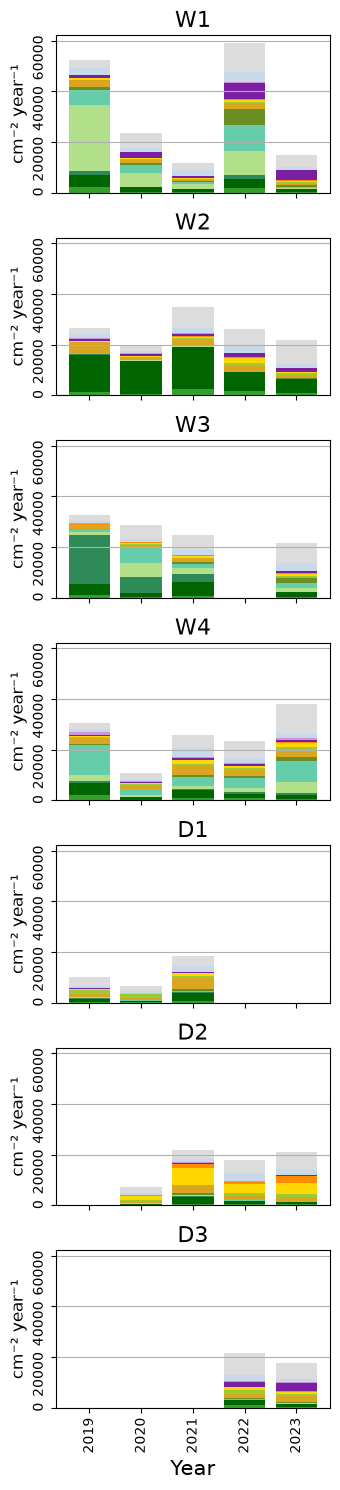

In [ ]:

unit = "cm⁻² year⁻¹"
all_years = [2019, 2020, 2021, 2022, 2023]

n_sites = len(site_order)
n_cols = 1 
n_rows = 7 

fig, axes = plt.subplots(n_rows, n_cols,figsize=(3.5, 15),sharex=True, sharey=True)
axes = axes.flatten()

for e, (sitei, ax) in enumerate(zip(site_order, axes)):
    dffig = df_all[df_all["site"] == sitei]

    df_pivot = dffig.pivot_table(index='year',columns='class',values='flux_cm2_an',fill_value=0)

    df_pivot = df_pivot.reindex(index=all_years,columns=fig_class_order,fill_value=0)

    plot_colors = [color_mapping[class_name] for class_name in df_pivot.columns]

    df_pivot.plot(kind='bar',stacked=True,color=plot_colors,ax=ax,legend=False,edgecolor='none',linewidth=0,width=0.8)

    ax.set_title(f'{sitei}',fontsize=16)
    ax.set_ylabel(f'{unit}', fontsize=12)
    ax.set_xlabel('Year', fontsize=15)
    ax.tick_params(axis='y', labelrotation=90)
    ax.grid(True, axis='y')
# plt.legend(title='', bbox_to_anchor=(1, 0), loc='lower left', ncol = 4, fontsize=12)


fig.tight_layout()
plt.savefig(p_save_fig/"annualflux_perSiteYear.pdf", bbox_inches="tight")

plt.show()


In [ ]:
# end